In [1]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import Holt
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error,mean_absolute_error, r2_score
import numpy as np

#load dataset
data = pd.read_excel("../df.xlsx")
df = data.iloc[27:,:] # from 1992-2025


df.set_index('Date', inplace=True)
df = df.sort_values('Date')

# Optional but recommended
#df = df.asfreq('6MS')

ts = df['Avg_Yield_Total']

# train / test split
train_size = int(len(ts) * 0.8)

train = ts.iloc[:train_size]
test = ts.iloc[train_size:]

In [2]:
# Multiplicative
model = Holt(
    train,
    damped_trend = True
).fit()





c:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [3]:
print(model.summary())

                              Holt Model Results                              
Dep. Variable:        Avg_Yield_Total   No. Observations:                   53
Model:                           Holt   SSE                        4228077.379
Optimized:                       True   AIC                            608.209
Trend:                       Additive   BIC                            618.061
Seasonal:                        None   AICC                           610.698
Seasonal Periods:                None   Date:                 Thu, 18 Jun 2026
Box-Cox:                        False   Time:                         11:52:21
Box-Cox Coeff.:                  None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.2792988                alpha                 True
smoothing_trend            0.2784484                

In [4]:
forecast = model.forecast(len(test))
forecast

c:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


53    4451.188000
54    4465.089607
55    4476.210892
56    4485.107921
57    4492.225543
58    4497.919642
59    4502.474920
60    4506.119143
61    4509.034521
62    4511.366824
63    4513.232666
64    4514.725340
65    4515.919479
66    4516.874790
dtype: float64

In [5]:
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = mean_absolute_percentage_error(test, forecast) * 100
mae = mean_absolute_error(test, forecast)
r2 = r2_score(test, forecast)

In [6]:
print("\nMultiplicative Model")

print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}")
print(f"MAE : {mae:.2f}")
print(f"R²   : {r2:.4f}")


Multiplicative Model
RMSE : 662.15
MAPE : 13.79
MAE : 504.23
R²   : -0.1830


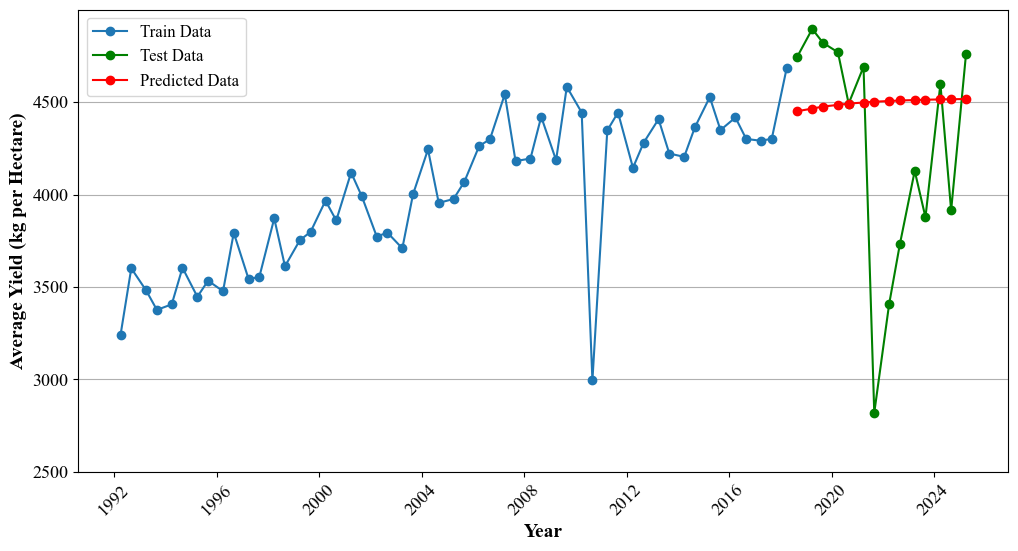

In [7]:
#Plot Forecast
plt.figure(figsize=(12,6))


plt.plot(train.index, train, label="Train Data",marker="o",linewidth=1.5)
plt.plot(test.index, test, label="Test Data", color="green",marker="o",linewidth=1.5)
plt.plot(test.index, forecast, label="Predicted Data", color="red",marker="o",linewidth=1.5)

plt.legend(prop={'size': 12, 'family':'Times New Roman'}  )

plt.ylim(2500,)


plt.xlabel("Year",fontsize=14,fontweight='bold',fontname='Times New Roman')
plt.ylabel("Average Yield (kg per Hectare)",fontsize=14,fontweight='bold',fontname='Times New Roman')

plt.grid(axis='y')
plt.xticks(rotation=45)

plt.xticks(fontsize=13, fontname='Times New Roman')
plt.yticks(fontsize=13, fontname='Times New Roman')

plt.show()

In [8]:
residuals = model.resid

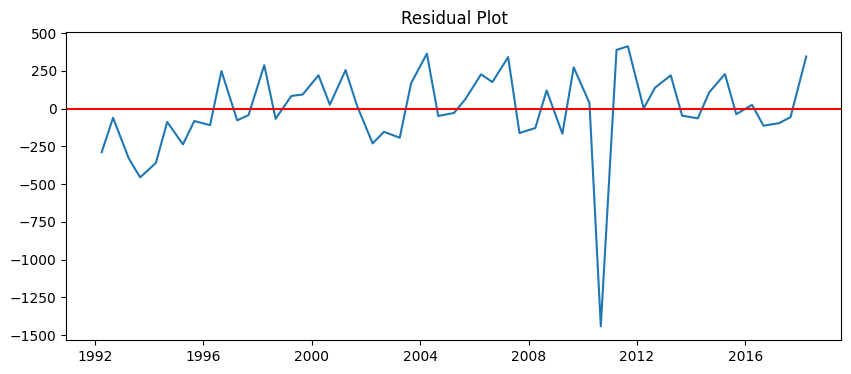

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(residuals)
plt.axhline(y=0, color='red')
plt.title("Residual Plot")
plt.show()

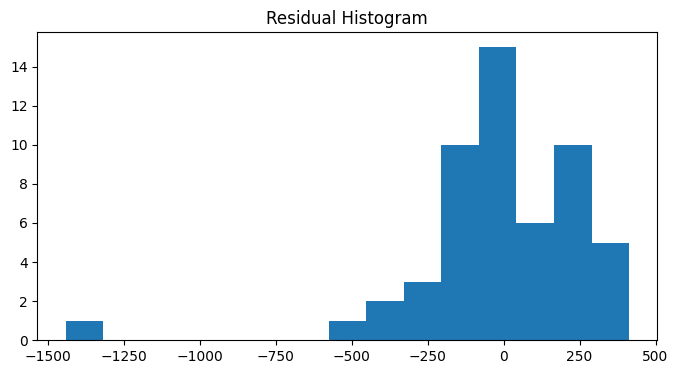

In [10]:
plt.figure(figsize=(8,4))
plt.hist(residuals, bins=15)
plt.title("Residual Histogram")
plt.show()

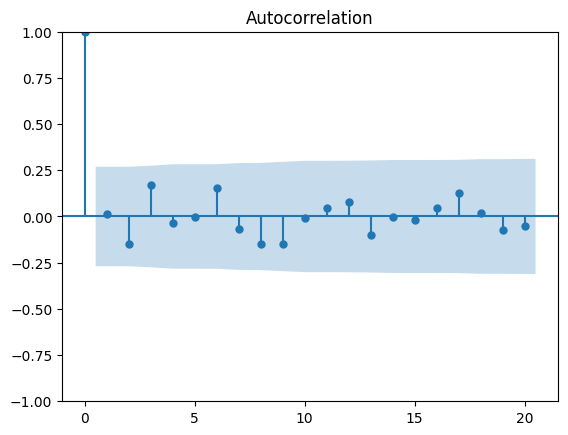

In [11]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(residuals, lags=20)
plt.show()

In [12]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb = acorr_ljungbox(residuals, lags=[10], return_df=True)
print(lb)

     lb_stat  lb_pvalue
10  7.768748   0.651414


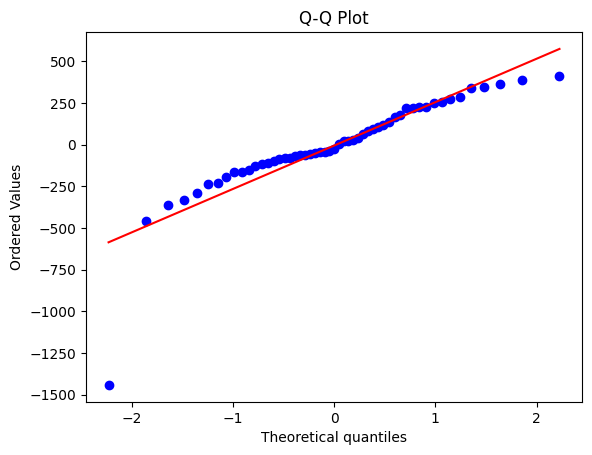

In [13]:
from scipy import stats

stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()